# Predictive Analysis

Because of the binary classification problem at hand, two methods naturally come to mind as predictive models: **Logistic Regression** and **Decision Trees**.

## Data Preparation

Because of the very low prevalence of **prediabetes (≈1.3% of patients)** in the dataset, these cases are removed from the analysis.

This simplifies the problem into a **binary classification problem**:

- 0 = No Diabetes  
- 1 = Diabetes

To address the class imbalance between diabetic and non-diabetic patients, the majority class is **randomly under-sampled**. This results in a balanced dataset containing approximately **70,000 observations**.

The dataset is split into **training and testing sets using an 80:20 split**. Afterwards, the training data is scaled using **Min-Max scaling** so that all features lie between **0 and 1**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

from imblearn.under_sampling import RandomUnderSampler

np.random.seed(1)

In [2]:
diab_df = pd.read_csv("data/diabetes_012_health_indicators_BRFSS2015.csv")
diab_df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Feature Selection

Based on discussion with health professionals, the following variables are chosen to predict the the risk of being diabetic:

- **BPxChol** – interaction between high blood pressure and high cholesterol  
- **Age** – age category of the patient  
- **GenHlth** – self-reported general health  
- **BMI** – body mass index

The interaction variable **BPxChol** is equal to **1 if both high blood pressure and high cholesterol are present**, and **0 otherwise**. This interaction captures the combined cardiovascular risk that may increase the likelihood of diabetes.

In [4]:
features = ["BPxChol", "Age", "GenHlth", "BMI"]

### Removing Prediabetes Cases

In [5]:
X = diab_df.loc[diab_df["Diabetes_012"].isin([0,2]), :]
y = diab_df.loc[diab_df["Diabetes_012"].isin([0,2]), "Diabetes_012"]

y = y.replace(2,1)

### Handling Class Imbalance

Random under-sampling is applied to obtain a balanced dataset.

In [6]:
undersampler = RandomUnderSampler()

X_resampled, y_resampled = undersampler.fit_resample(X, y)

print(X_resampled.shape)

(70692, 29)


### Train-Test Split and Scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2
)

scaler = MinMaxScaler()

X_train_sc = scaler.fit_transform(X_train[features])
X_test_sc = scaler.transform(X_test[features])

# Logistic Regression Model

Logistic Regression is trained as a **baseline model** for comparison.

The model estimates the probability that a patient belongs to the diabetic class using a sigmoid function applied to a linear combination of the features.

In [8]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_sc, y_train)

y_pred_log = log_model.predict(X_test_sc)

### Logistic Regression Evaluation

In [9]:
log_accuracy = accuracy_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression F1-score:", log_f1)

print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7383124690572176
Logistic Regression F1-score: 0.7418724710478583
              precision    recall  f1-score   support

         0.0       0.74      0.73      0.73      7058
         1.0       0.73      0.75      0.74      7081

    accuracy                           0.74     14139
   macro avg       0.74      0.74      0.74     14139
weighted avg       0.74      0.74      0.74     14139



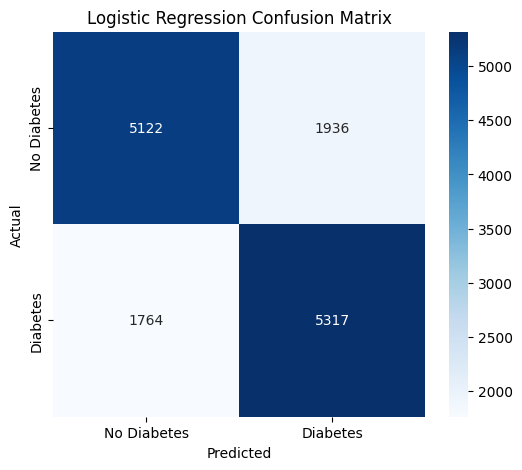

In [10]:
conf_matrix_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(conf_matrix_log,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Diabetes","Diabetes"],
            yticklabels=["No Diabetes","Diabetes"])

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Random Forest Model

To capture complex relationships between the health indicators, a **Random Forest model** is trained.

Random Forests consist of multiple decision trees trained on random subsets of the data. The final prediction is obtained by averaging the predictions of the individual trees.

Hyperparameters are optimized using `GridSearchCV`.

In [11]:
param_grid = {
    'n_estimators': [20,50,100],
    'max_depth': [3,4,5,6],
    'max_leaf_nodes': [8,12,16],
    'max_features': [None,'sqrt','log2'],
    'criterion': ['gini','entropy']
}

rf = RandomForestClassifier(random_state=1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sc, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
{'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'max_leaf_nodes': 16, 'n_estimators': 100}


### Final Random Forest Model

In [ ]:
model = RandomForestClassifier(
    criterion="gini",
    max_features="sqrt",
    max_leaf_nodes=16,
    max_depth=6,
    n_estimators=100
)

scores = cross_validate(model, X_train_sc, y_train, cv=5, scoring=['accuracy','f1_macro'])

model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

### Random Forest Evaluation

In [13]:
rf_accuracy = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest F1-score:", rf_f1)

print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.7293302213735059
Random Forest F1-score: 0.732396335920565
              precision    recall  f1-score   support

         0.0       0.73      0.72      0.73      7058
         1.0       0.73      0.74      0.73      7081

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



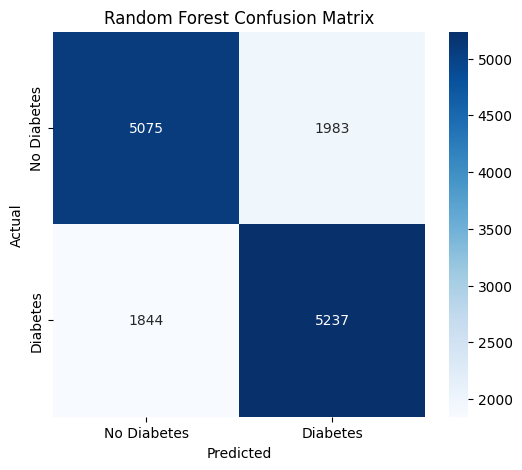

In [14]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(conf_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Diabetes","Diabetes"],
            yticklabels=["No Diabetes","Diabetes"])

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Comparison

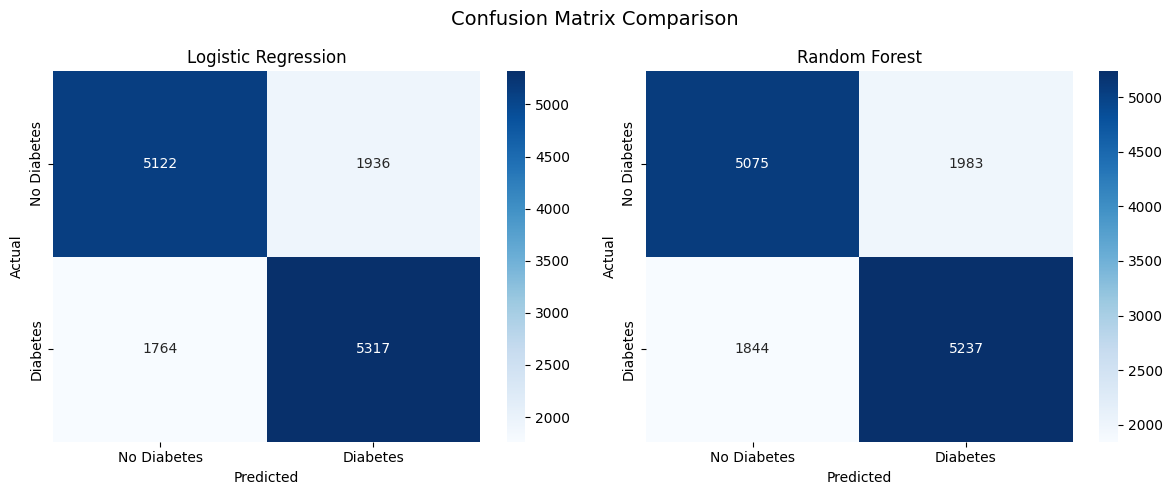

Model Comparison

Logistic Regression Accuracy: 0.7383124690572176
Random Forest Accuracy: 0.7293302213735059

Logistic Regression F1: 0.7418724710478583
Random Forest F1: 0.732396335920565


In [ ]:
# compute confusion matrices
cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

labels = ["No Diabetes", "Diabetes"]

# Logistic Regression matrix
sns.heatmap(cm_log,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[0])

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest matrix
sns.heatmap(cm_rf,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[1])

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)

plt.tight_layout()
plt.show()

print("Model Comparison\n")
print("\nLogistic Regression F1:", log_f1)
print("Random Forest F1:", rf_f1)
print("Logistic Regression Accuracy:", log_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

## Conclusion

In this analysis, two classification approaches were considered for predicting whether a patient is diabetic: **Logistic Regression** and **Decision Tree–based models**. Logistic Regression is a widely used method for binary classification and estimates the probability of class membership by fitting a sigmoid function to the input features. Because of its simplicity, it serves as a strong baseline model for many predictive tasks.

Decision Trees, in contrast, classify observations by recursively splitting the data according to feature values, forming a set of easily interpretable decision rules. This structure allows for clear visualization and intuitive interpretation of how different health indicators contribute to the final prediction. However, individual decision trees can be prone to overfitting when they become too complex.

To address this limitation, a **Random Forest** model was employed. A Random Forest is an ensemble method that combines multiple decision trees, each trained on a random subset of the data. By averaging the predictions of these trees, the model reduces variance and improves generalization performance. This approach preserves the interpretability advantages of decision trees while mitigating their tendency to overfit.

When comparing the two models, the Random Forest, while performing **similar accuracy** than Logistic Regression, maintains a relatively interpretable structure through its individual decision trees. Additionally, the model is able to capture **non-linear relationships and interaction effects** between health indicators, which Logistic Regression may not fully represent.

For these reasons the **Random Forest** model was selected as the final predictive model for this analysis.